<div style="background:linear-gradient(135deg,#0D2B55 0%,#1F497D 60%,#2E86C1 100%);color:#fff;padding:26px 30px;border-radius:10px;">
<div style="font-size:26px;font-weight:700;">Financial Risk Management and Engineering - Session 11</div>
<div style="font-size:20px;font-weight:600;margin-top:4px;">Regulatory Risk, Stress Testing, Systemic &amp; Model Risk</div>
<div style="font-size:13px;opacity:0.9;margin-top:10px;">Sprott School of Business &middot; Carleton University &middot; Summer 2026</div>
<div style="font-size:13px;opacity:0.85;margin-top:8px;">Basel III capital ratios &middot; VaR vs Stressed VaR &middot; FRTB ES &middot; Scenario &amp; reverse stress tests &middot; CoVaR / &Delta;CoVaR &middot; MES / SRISK &middot; Model risk &middot; Regime detection</div>
</div>

This single notebook combines the regulatory / stress-testing toolkit with the systemic-risk, model-risk and regime-detection toolkit. Run cells top to bottom.

<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Setup - Source Material, Packages &amp; Environment Check</span><br><span style="color:#BDC3C7;font-size:0.93em">Run this first &middot; works on any recent Python 3.9+</span></div>

<div style="background:#0D2B45;border-left:5px solid #2E86C1;padding:13px 20px;color:#EAF2FB;border-radius:4px;">
&#128218; <b>Source material.</b> &nbsp; This session follows <b>Hull (2023), Risk Management and Financial Institutions (6th ed.)</b>: Ch.&nbsp;16 (Scenario Analysis &amp; Stress Testing), Ch.&nbsp;22 (Model Risk), Ch.&nbsp;23 (Climate Risk &amp; ESG), Ch.&nbsp;25 (Basel I &amp; II), Ch.&nbsp;26 (Basel II.5 &amp; III); and <b>Jorion (2010), Financial Risk Manager Handbook (6th ed.)</b>: Ch.&nbsp;27 (Firmwide Risk) &amp; Ch.&nbsp;28 (The Basel Accord). Climate / ESG risk is treated on the slides; the code below covers the quantitative parts.
</div>

This notebook uses the standard scientific-Python stack. If you installed **[Anaconda](https://www.anaconda.com/download)** most of these are already present; otherwise install everything in one line (from a terminal, or prefix with `!` in a cell):

```
pip install yfinance pandas numpy matplotlib seaborn scipy statsmodels scikit-learn
```

No installs allowed on your machine? **[Google Colab](https://colab.research.google.com)** runs this notebook free in the browser - upload the `.ipynb` and add a first cell with `!pip install yfinance pandas numpy matplotlib seaborn scipy statsmodels scikit-learn`.

<div style="background:#0A2A1A;border-left:5px solid #1E8449;padding:12px 18px;border-radius:0 8px 8px 0;margin:10px 0"><span style="color:#52C97A;font-weight:bold">&#10003; Environment check &nbsp;</span><span style="color:#90D4A8;line-height:1.7">Run the cell below. Every line should print a version number. Anything marked <code>NOT INSTALLED</code> tells you exactly what to <code>pip install</code>, then <b>Kernel &rarr; Restart &amp; Run All</b>.</span></div>

In [1]:
import importlib, sys
print('Python', sys.version.split()[0], '\n')
for pkg in ['numpy', 'pandas', 'matplotlib', 'scipy', 'yfinance', 'seaborn', 'statsmodels', 'sklearn']:
    try:
        m = importlib.import_module(pkg)
        print(f'  {pkg:13s} {getattr(m, "__version__", "ok")}')
    except Exception:
        print(f'  {pkg:13s} NOT INSTALLED  ->  pip install {pkg}')

Python 3.13.3 

  numpy         2.4.6


  pandas        3.0.3
  matplotlib    3.10.0
  scipy         1.17.1


  yfinance      0.2.55


  seaborn       0.13.2
  statsmodels   0.14.6
  sklearn       1.8.0


<div style="border-left:5px solid #D4A017;background:#1C1400;padding:8px 14px;border-radius:0 5px 5px 0;margin:4px 0"><b style="color:#F0B429">&#128172;</b> <b>When things break.</b> <b>Run cells top to bottom</b> - order matters. If results look wrong, <b>Kernel &rarr; Restart &amp; Run All</b>. Common errors: <code>ModuleNotFoundError</code> &rarr; <code>pip install &lt;name&gt;</code> then restart; <code>NameError</code> &rarr; you skipped the cell that defines it; <code>YFRateLimitError</code> &rarr; Yahoo throttled you, wait a minute - this notebook caches data in <code>notebook_data/</code> so a re-run works offline. Read the <b>last</b> line of a traceback first.</div>

In [2]:
import warnings; warnings.filterwarnings('ignore')
import os, time
import numpy as np, pandas as pd, yfinance as yf
import matplotlib.pyplot as plt, matplotlib.cm as cm
import seaborn as sns, statsmodels.api as sm
from scipy.stats import norm, t as t_dist
from statsmodels.regression.quantile_regression import QuantReg
from sklearn.mixture import GaussianMixture
np.random.seed(42)

plt.rcParams.update({'figure.figsize': (13, 5), 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 12})
NAVY, BLUE, GREEN, RED, GOLD, PURPLE = '#0D2B55','#2C7BB6','#1A9641','#D7191C','#F4A442','#762A83'
START, EXTENDED_START, END = '2021-07-01', '2019-12-01', '2026-07-01'
RF_ANNUAL = 0.04; RF_DAILY = RF_ANNUAL / 252
CACHE_DIR = 'notebook_data'; os.makedirs(CACHE_DIR, exist_ok=True)

def download_with_retry(tickers, start, end, retries=3):
    for attempt in range(1, retries + 1):
        try:
            raw = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)['Close']
            raw = raw.dropna(how='all')
            if len(raw) > 10:
                return raw
        except Exception as e:
            print(f'Attempt {attempt} failed: {e}')
        if attempt < retries: time.sleep(3)
    raise RuntimeError('Download failed after retries.')

def load_prices(fname, tickers, start, end):
    path = os.path.join(CACHE_DIR, fname)
    if os.path.exists(path):
        px = pd.read_csv(path, index_col=0, parse_dates=True)
    else:
        px = download_with_retry(tickers, start, end); px.to_csv(path)
    return px[tickers]

# Trading portfolio for the regulatory / stress-testing sections
PORTFOLIO = {'JPM': 0.30, 'GS': 0.20, 'SPY': 0.20, 'TLT': 0.20, 'GLD': 0.10}
TICKERS = list(PORTFOLIO); WEIGHTS = np.array(list(PORTFOLIO.values()))
prices_ext = load_prices('Session_11_extended.csv', TICKERS, EXTENDED_START, END)
rets_ext = prices_ext.pct_change().dropna()
port_rets = rets_ext[TICKERS] @ WEIGHTS
port_ext = port_rets

# Bank universe + market proxy for the systemic / model-risk sections
BANK_TICKERS = ['JPM', 'BAC', 'GS', 'C', 'MS']
BANK_NAMES = {'JPM':'JPMorgan','BAC':'Bank of America','GS':'Goldman Sachs','C':'Citigroup','MS':'Morgan Stanley'}
ALL_TICKERS = BANK_TICKERS + ['^GSPC']
prices_sys = load_prices('Session_11_banks.csv', ALL_TICKERS, START, END).ffill(limit=5).dropna()
rets = np.log(prices_sys / prices_sys.shift(1)).dropna()
system_ret = rets['^GSPC']; bank_rets = rets[BANK_TICKERS]
r_spy = system_ret; r_focal = bank_rets['JPM']

print(f'Portfolio {TICKERS}: {rets_ext.index[0].date()} to {rets_ext.index[-1].date()} ({len(rets_ext)} days)')
print(f'Banks {BANK_TICKERS} + ^GSPC: {rets.index[0].date()} to {rets.index[-1].date()} ({len(rets)} days)')

Portfolio ['JPM', 'GS', 'SPY', 'TLT', 'GLD']: 2019-12-03 to 2026-06-30 (1651 days)
Banks ['JPM', 'BAC', 'GS', 'C', 'MS'] + ^GSPC: 2021-07-02 to 2026-06-30 (1253 days)


---
## Part 1 - Regulatory Capital: Definitions and Ratios

<div style="background:#EBF5FB;border-left:6px solid #2C7BB6;padding:14px 18px;border-radius:6px;margin:10px 0">
<b style="color:#1A5276">Key Concepts</b><br>
<b>Risk-Weighted Assets (RWA)</b>: each asset is multiplied by a regulatory risk weight (0–150 %) to produce a risk-adjusted exposure base for capital purposes.<br>
<b>CET1 ratio</b> = CET1 Capital / RWA &nbsp;≥&nbsp; 4.5 % (hard min) + 2.5 % conservation buffer = 7.0 % effective floor.<br>
<b>Tier-1 ratio</b> = Tier-1 Capital / RWA &nbsp;≥&nbsp; 6.0 %.<br>
<b>Total Capital ratio</b> = (Tier-1 + Tier-2) / RWA &nbsp;≥&nbsp; 8.0 %.<br>
<b>Leverage ratio</b> = Tier-1 / Total Exposure &nbsp;≥&nbsp; 3.0 % (Basel III).<br>
<b>LCR</b> (Liquidity Coverage Ratio) = HQLA / Net 30-day outflows &nbsp;≥&nbsp; 100 %.<br>
<b>NSFR</b> (Net Stable Funding Ratio) = Available Stable Funding / Required Stable Funding &nbsp;≥&nbsp; 100 %.
</div>

### Worked Numerical Example - Illustrative Bank Balance Sheet

We build a stylised bank and compute all five Basel III ratios, flagging pass / fail.

Total Assets $660Bn | RWA $286Bn | CET1 15.8%
                    Actual  Minimum  Buffer Pass/Fail
CET1 Ratio (%)       15.76      7.0    8.76      PASS
Tier-1 Ratio (%)     18.21      8.5    9.71      PASS
Total Capital (%)    21.72     10.5   11.22      PASS
Leverage Ratio (%)    6.84      3.0    3.84      PASS
LCR (%)             123.08    100.0   23.08      PASS
NSFR (%)            107.69    100.0    7.69      PASS


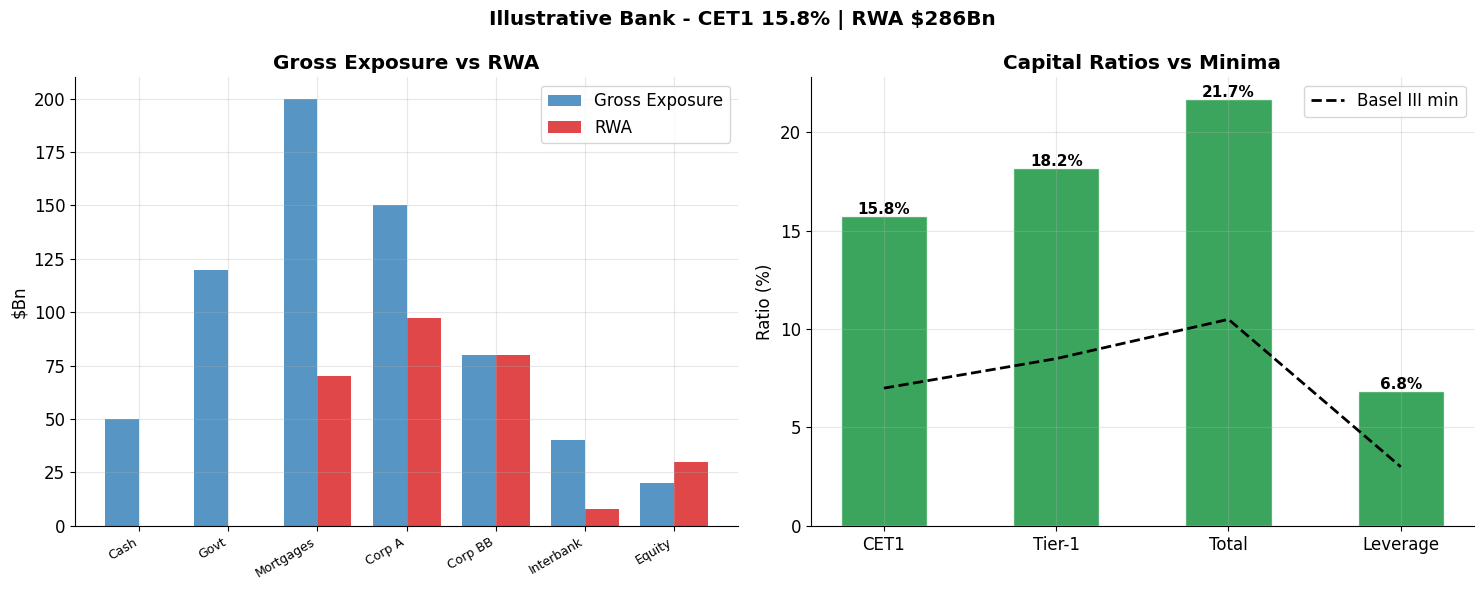

In [3]:
bs = pd.DataFrame({
    'Asset Class': ['Cash & Reserves','Govt Bonds (0%)','Mortgages (LTV<80%)','Corp Loans (A)','Corp Loans (BB)','Interbank','Equity'],
    'Exposure_Bn': [50,120,200,150,80,40,20],
    'Risk_Weight_pct': [0,0,35,65,100,20,150]})
bs['RWA_Bn'] = bs['Exposure_Bn'] * bs['Risk_Weight_pct']/100
total_assets = bs['Exposure_Bn'].sum(); total_rwa = bs['RWA_Bn'].sum()
cet1_capital, tier1_capital, total_capital = 45.0, 52.0, 62.0
leverage_exposure = total_assets + 100
cet1_ratio = cet1_capital/total_rwa*100
tier1_ratio = tier1_capital/total_rwa*100
total_cap_ratio = total_capital/total_rwa*100
leverage_ratio = tier1_capital/leverage_exposure*100
hqla, net_30d_outflows, avail_stable, req_stable = 80.0, 65.0, 420.0, 390.0
lcr = hqla/net_30d_outflows*100; nsfr = avail_stable/req_stable*100
MINIMA = {'CET1 Ratio (%)':7.0,'Tier-1 Ratio (%)':8.5,'Total Capital (%)':10.5,'Leverage Ratio (%)':3.0,'LCR (%)':100.0,'NSFR (%)':100.0}
ACTUALS = {'CET1 Ratio (%)':cet1_ratio,'Tier-1 Ratio (%)':tier1_ratio,'Total Capital (%)':total_cap_ratio,'Leverage Ratio (%)':leverage_ratio,'LCR (%)':lcr,'NSFR (%)':nsfr}
ratio_df = pd.DataFrame({'Actual':ACTUALS,'Minimum':MINIMA})
ratio_df['Buffer'] = ratio_df['Actual'] - ratio_df['Minimum']
ratio_df['Pass/Fail'] = np.where(ratio_df['Actual']>=ratio_df['Minimum'],'PASS','FAIL')
print(f'Total Assets ${total_assets:.0f}Bn | RWA ${total_rwa:.0f}Bn | CET1 {cet1_ratio:.1f}%')
print(ratio_df[['Actual','Minimum','Buffer','Pass/Fail']].round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
short_names = ['Cash','Govt','Mortgages','Corp A','Corp BB','Interbank','Equity']
x = np.arange(len(bs)); w = 0.38
axes[0].bar(x-w/2, bs['Exposure_Bn'], w, color=BLUE, alpha=0.8, label='Gross Exposure')
axes[0].bar(x+w/2, bs['RWA_Bn'], w, color=RED, alpha=0.8, label='RWA')
axes[0].set_xticks(x); axes[0].set_xticklabels(short_names, rotation=30, ha='right', fontsize=9)
axes[0].set_ylabel('$Bn'); axes[0].set_title('Gross Exposure vs RWA', fontweight='bold'); axes[0].legend()
ratios_to_plot = ['CET1 Ratio (%)','Tier-1 Ratio (%)','Total Capital (%)','Leverage Ratio (%)']
vals = [ACTUALS[r] for r in ratios_to_plot]; mins = [MINIMA[r] for r in ratios_to_plot]
xa = np.arange(len(ratios_to_plot))
bars = axes[1].bar(xa, vals, color=[GREEN if a>=m else RED for a,m in zip(vals,mins)], alpha=0.85, edgecolor='white', width=0.5)
axes[1].plot(xa, mins, 'k--', lw=2, label='Basel III min')
for bar,v in zip(bars,vals): axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[1].set_xticks(xa); axes[1].set_xticklabels(['CET1','Tier-1','Total','Leverage'])
axes[1].set_ylabel('Ratio (%)'); axes[1].set_title('Capital Ratios vs Minima', fontweight='bold'); axes[1].legend()
plt.suptitle(f'Illustrative Bank - CET1 {cet1_ratio:.1f}% | RWA ${total_rwa:.0f}Bn', fontweight='bold')
plt.tight_layout(); plt.show()

---
## Part 2 - Market-Risk Capital: VaR, Stressed VaR, and FRTB Expected Shortfall

<div style="background:#EAFAF1;border-left:6px solid #1A9641;padding:14px 18px;border-radius:6px;margin:10px 0">
<b style="color:#145A32">Regulation</b><br>
<b>Basel 2.5 (2009)</b> introduced <em>Stressed VaR</em> alongside standard VaR. The market-risk capital charge became:<br>
$$MRC = \max\!\left(VaR_{t-1},\; m_c \cdot \frac{1}{60}\sum_{i=1}^{60}VaR_{t-i}\right) + \max\!\left(SVaR_{t-1},\; m_s \cdot \frac{1}{60}\sum_{i=1}^{60}SVaR_{t-i}\right)$$
where $m_c, m_s \geq 3$ (multipliers set by supervisor based on back-test exceptions).<br><br>
<b>FRTB (Basel IV, 2019)</b> replaces VaR with <em>Expected Shortfall at 97.5 %</em> estimated on a stressed calibration period:
$$ES_{97.5\%} = -\frac{1}{1-0.975}\int_{0.975}^{1} VaR_u \, du \approx \text{mean of worst 2.5\% losses}$$
</div>

Calm 1d VaR99 1.486% | Stressed 1d VaR99 2.813% | FRTB 1d ES97.5 2.884%
10d Stressed VaR 8.896% | 10d ES 9.120% | MRC 40.788% | SVaR/VaR 1.9x


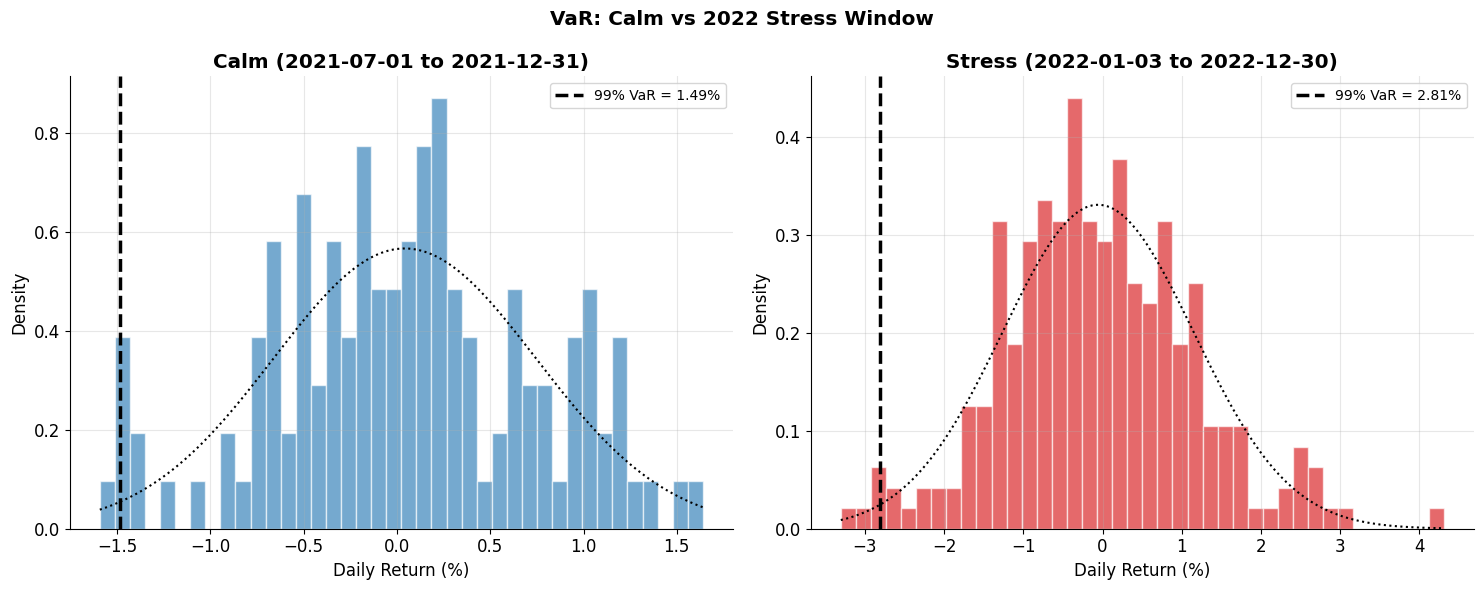

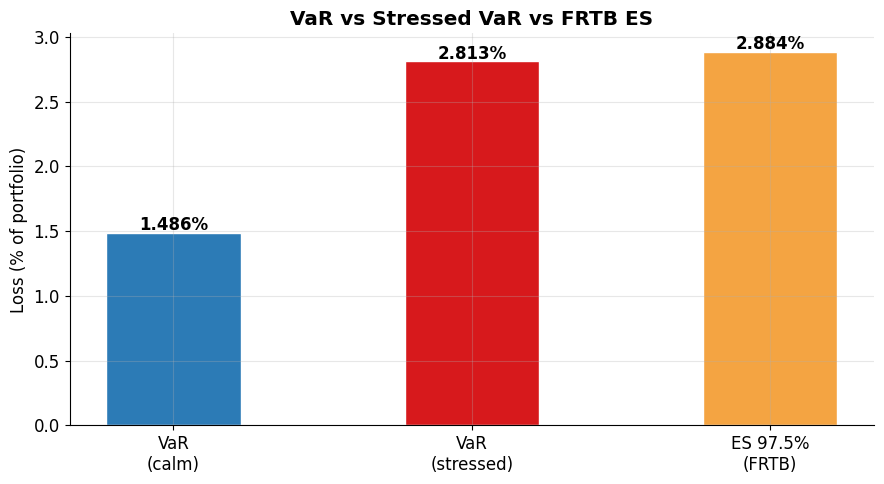

In [4]:
CALM_START, CALM_END = '2021-07-01', '2021-12-31'
STRESS_START, STRESS_END = '2022-01-03', '2022-12-30'
port_calm = port_rets.loc[CALM_START:CALM_END]
port_stress = port_rets.loc[STRESS_START:STRESS_END]
CONF, CONF_FRTB, HORIZON = 0.99, 0.975, 10

def historical_var(r, conf=0.99):
    return -np.percentile(r, (1-conf)*100)
def historical_es(r, conf=0.975):
    thr = np.percentile(r, (1-conf)*100); return -r[r<=thr].mean()
def scale_to_horizon(m, h=10):
    return m*np.sqrt(h)

var_calm = historical_var(port_calm, CONF); var_stress = historical_var(port_stress, CONF)
es_frtb = historical_es(port_stress, CONF_FRTB)
var_stress_10d = scale_to_horizon(var_stress); es_10d = scale_to_horizon(es_frtb)
mrc = 3.0*scale_to_horizon(var_calm) + 3.0*var_stress_10d
print(f'Calm 1d VaR99 {var_calm*100:.3f}% | Stressed 1d VaR99 {var_stress*100:.3f}% | FRTB 1d ES97.5 {es_frtb*100:.3f}%')
print(f'10d Stressed VaR {var_stress_10d*100:.3f}% | 10d ES {es_10d*100:.3f}% | MRC {mrc*100:.3f}% | SVaR/VaR {var_stress/var_calm:.1f}x')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (r, label, color, var_val) in zip(axes,
        [(port_calm, f'Calm ({CALM_START} to {CALM_END})', BLUE, var_calm),
         (port_stress, f'Stress ({STRESS_START} to {STRESS_END})', RED, var_stress)]):
    ax.hist(r*100, bins=40, color=color, alpha=0.65, edgecolor='white', density=True)
    ax.axvline(-var_val*100, color='black', lw=2.5, ls='--', label=f'99% VaR = {var_val*100:.2f}%')
    xs = np.linspace(r.min(), r.max(), 200)*100
    ax.plot(xs, norm.pdf(xs, r.mean()*100, r.std()*100), color='black', lw=1.5, ls=':')
    ax.set_xlabel('Daily Return (%)'); ax.set_ylabel('Density'); ax.set_title(label, fontweight='bold'); ax.legend(fontsize=10)
plt.suptitle('VaR: Calm vs 2022 Stress Window', fontweight='bold'); plt.tight_layout(); plt.show()

measures = ['VaR\n(calm)','VaR\n(stressed)','ES 97.5%\n(FRTB)']
values = [var_calm*100, var_stress*100, es_frtb*100]
fig2, ax2 = plt.subplots(figsize=(9, 5))
bars = ax2.bar(measures, values, color=[BLUE,RED,GOLD], edgecolor='white', width=0.45)
for bar,v in zip(bars,values): ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{v:.3f}%', ha='center', fontweight='bold')
ax2.set_ylabel('Loss (% of portfolio)'); ax2.set_title('VaR vs Stressed VaR vs FRTB ES', fontweight='bold')
plt.tight_layout(); plt.show()

---
## Part 3 - Scenario / Stress Testing

<div style="background:#FDEDEC;border-left:6px solid #D7191C;padding:14px 18px;border-radius:6px;margin:10px 0">
<b style="color:#7B241C">Stress Testing Framework</b><br>
Stress tests answer: <em>"What happens to my portfolio if scenario X materialises?"</em><br>
We use <b>three approaches</b>:<br>
1. <b>Historical replay</b>: replay the actual returns from a past crisis window (COVID-2020 crash; 2022 rate/equity bear).<br>
2. <b>Hypothetical factor shocks</b>: equities −30 %, long rates +200 bp (proxied via TLT duration), credit spread widening.<br>
3. <b>Sensitivity grid</b>: a 2-D heatmap of P&amp;L over a grid of factor shocks.
</div>

### 3a - Historical Replay: COVID-2020 and 2022 Drawdown

  COVID crash (Feb-Mar 2020)       Total -26.58%  MaxDD -27.25%  (24d)
  2022 drawdown (Jan-Oct 2022)     Total -23.33%  MaxDD -27.65%  (197d)


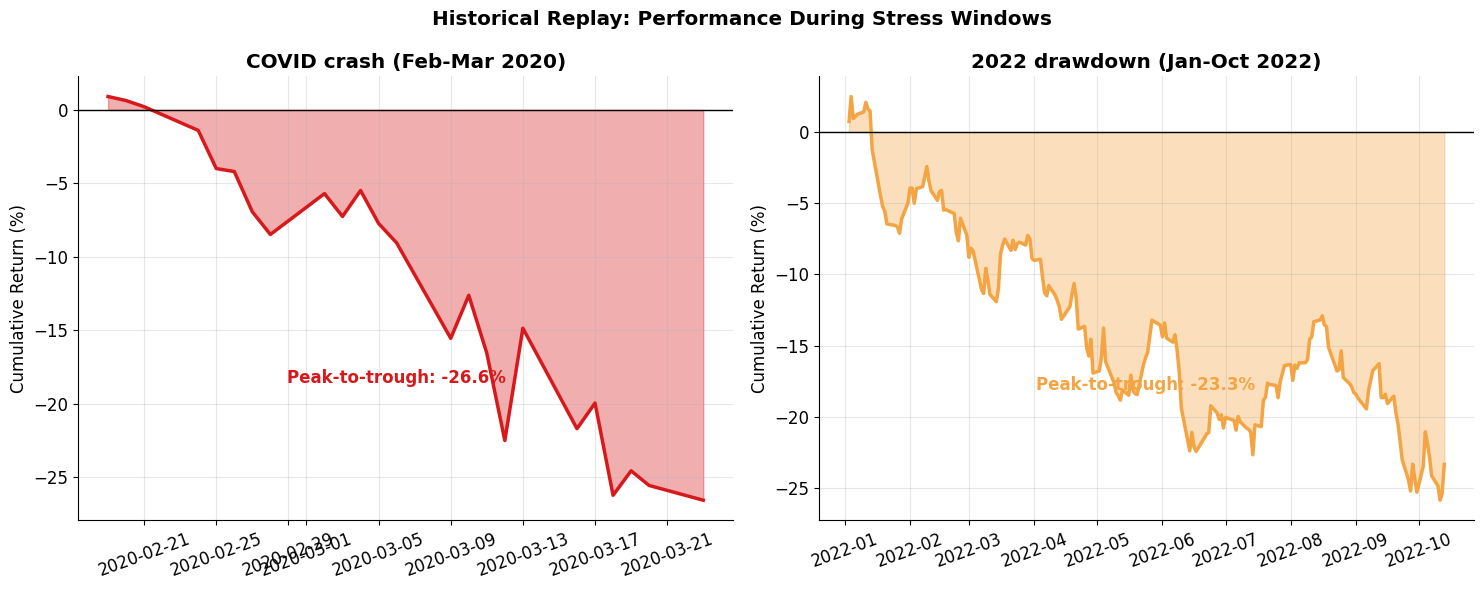

In [5]:
SCENARIOS = {'COVID crash (Feb-Mar 2020)':('2020-02-19','2020-03-23'),
             '2022 drawdown (Jan-Oct 2022)':('2022-01-03','2022-10-13')}
scenario_results = {}
for name,(s,e) in SCENARIOS.items():
    wr = port_ext.loc[s:e]
    cum_loss = (1+wr).prod()-1
    max_dd = ((1+wr).cumprod()/(1+wr).cumprod().cummax()-1).min()
    scenario_results[name] = {'Total Return':cum_loss,'Max Drawdown':max_dd,'Days':len(wr)}
    print(f'  {name:<32} Total {cum_loss*100:+.2f}%  MaxDD {max_dd*100:+.2f}%  ({len(wr)}d)')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax,((name,(s,e)),col) in zip(axes, zip(SCENARIOS.items(),[RED,GOLD])):
    cum = (1+port_ext.loc[s:e]).cumprod()-1
    ax.fill_between(cum.index, cum*100, color=col, alpha=0.35)
    ax.plot(cum.index, cum*100, color=col, lw=2.5); ax.axhline(0, color='black', lw=1)
    ax.text(cum.index[len(cum)//2], cum.min()*100*0.7, f'Peak-to-trough: {cum.iloc[-1]*100:.1f}%', ha='center', fontweight='bold', color=col)
    ax.set_title(name, fontweight='bold'); ax.set_ylabel('Cumulative Return (%)'); ax.tick_params(axis='x', rotation=20)
plt.suptitle('Historical Replay: Performance During Stress Windows', fontweight='bold'); plt.tight_layout(); plt.show()

### 3b - Hypothetical Factor Shocks

Asset factor betas:
     beta_eq  beta_rate
JPM    1.032     -0.323
GS     1.190     -0.123
SPY    1.000      0.000
TLT    0.000      1.000
GLD    0.155      0.245
  Equity -30%      Portfolio P&L -22.89%
  Rates +200bp     Portfolio P&L -2.06%
  Combined shock   Portfolio P&L -24.95%
  Mild stress      Portfolio P&L -8.15%


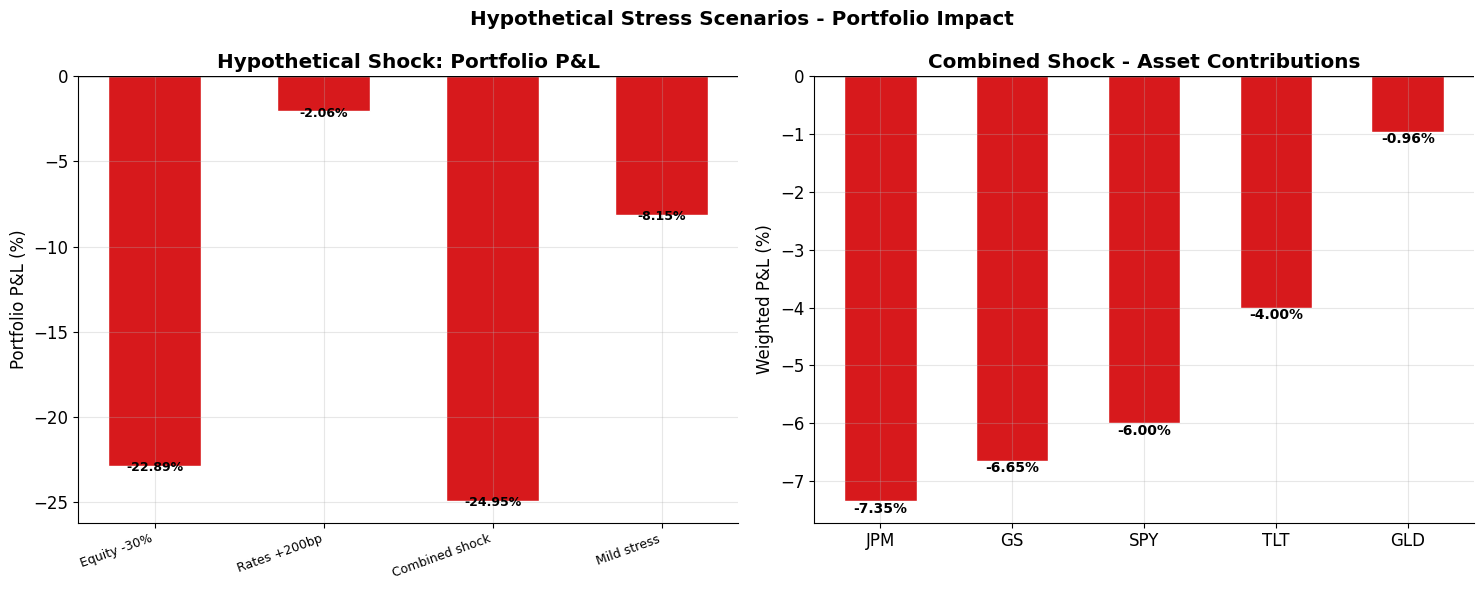

In [6]:
X = sm.add_constant(pd.concat([rets_ext['SPY'], rets_ext['TLT']], axis=1)); X.columns = ['const','equity_factor','rate_factor']
betas = {}
for t in TICKERS:
    aligned = X.join(rets_ext[t]).dropna()
    res = sm.OLS(aligned[t], aligned[['const','equity_factor','rate_factor']]).fit()
    betas[t] = {'beta_eq':res.params['equity_factor'],'beta_rate':res.params['rate_factor']}
betas_df = pd.DataFrame(betas).T
print('Asset factor betas:'); print(betas_df.round(3).to_string())

SPY_CRASH, TLT_DUR_200BP = -0.30, -0.20
hypo_scenarios = {'Equity -30%':(SPY_CRASH,0.0),'Rates +200bp':(0.0,TLT_DUR_200BP),
                  'Combined shock':(SPY_CRASH,TLT_DUR_200BP),'Mild stress':(-0.10,-0.05)}
hypo_results = {}
for scen,(d_eq,d_rate) in hypo_scenarios.items():
    per_asset = {t:(betas_df.loc[t,'beta_eq']*d_eq + betas_df.loc[t,'beta_rate']*d_rate)*w for t,w in PORTFOLIO.items()}
    total = sum(per_asset.values()); hypo_results[scen] = {'total_pnl':total,'per_asset':per_asset}
    print(f'  {scen:<16} Portfolio P&L {total*100:+.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
labels = list(hypo_scenarios); tot = [hypo_results[s]['total_pnl']*100 for s in labels]
bars = axes[0].bar(range(len(labels)), tot, color=[RED if p<0 else GREEN for p in tot], edgecolor='white', width=0.55)
axes[0].axhline(0, color='black', lw=1); axes[0].set_xticks(range(len(labels))); axes[0].set_xticklabels(labels, rotation=20, ha='right', fontsize=9)
axes[0].set_ylabel('Portfolio P&L (%)'); axes[0].set_title('Hypothetical Shock: Portfolio P&L', fontweight='bold')
for bar,v in zip(bars,tot): axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+(0.1 if v>=0 else -0.3), f'{v:+.2f}%', ha='center', fontsize=9, fontweight='bold')
asset_pnls = [hypo_results['Combined shock']['per_asset'][t]*100 for t in TICKERS]
axes[1].bar(TICKERS, asset_pnls, color=[RED if p<0 else GREEN for p in asset_pnls], edgecolor='white', width=0.55)
axes[1].axhline(0, color='black', lw=1); axes[1].set_ylabel('Weighted P&L (%)'); axes[1].set_title('Combined Shock - Asset Contributions', fontweight='bold')
for i,v in enumerate(asset_pnls): axes[1].text(i, v+(0.05 if v>=0 else -0.2), f'{v:+.2f}%', ha='center', fontsize=10, fontweight='bold')
plt.suptitle('Hypothetical Stress Scenarios - Portfolio Impact', fontweight='bold'); plt.tight_layout(); plt.show()

### 3c - Sensitivity Grid (2-Factor Heatmap)

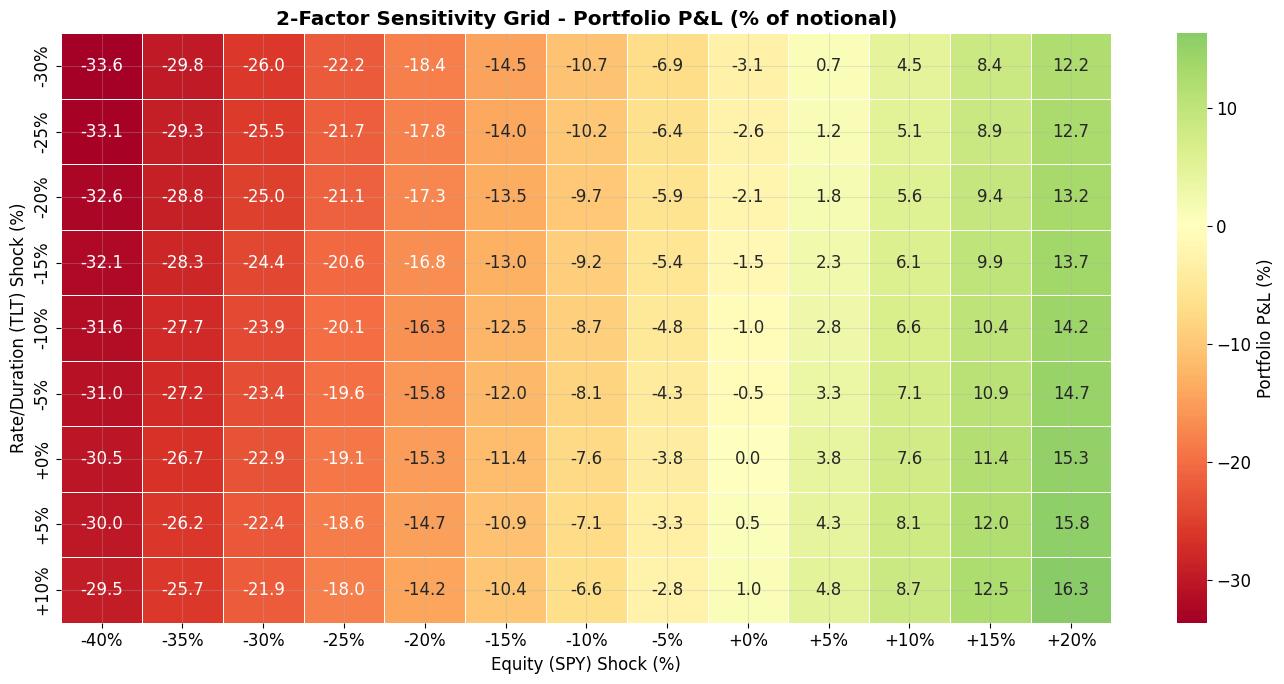

Worst cell: -33.62% (equity -40%, rate -30%)


In [7]:
eq_shocks = np.linspace(-0.40, 0.20, 13); rate_shocks = np.linspace(-0.30, 0.10, 9)
pnl_grid = np.zeros((len(rate_shocks), len(eq_shocks)))
for i,d_rate in enumerate(rate_shocks):
    for j,d_eq in enumerate(eq_shocks):
        pnl_grid[i,j] = sum((betas_df.loc[t,'beta_eq']*d_eq + betas_df.loc[t,'beta_rate']*d_rate)*w for t,w in PORTFOLIO.items())*100
pnl_df_grid = pd.DataFrame(pnl_grid, index=[f'{r*100:+.0f}%' for r in rate_shocks], columns=[f'{e*100:+.0f}%' for e in eq_shocks])
fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pnl_df_grid, annot=True, fmt='.1f', cmap='RdYlGn', center=0, linewidths=0.4, ax=ax, cbar_kws={'label':'Portfolio P&L (%)'})
ax.set_xlabel('Equity (SPY) Shock (%)'); ax.set_ylabel('Rate/Duration (TLT) Shock (%)')
ax.set_title('2-Factor Sensitivity Grid - Portfolio P&L (% of notional)', fontweight='bold')
plt.tight_layout(); plt.show()
imin = np.unravel_index(pnl_grid.argmin(), pnl_grid.shape)
print(f'Worst cell: {pnl_grid.min():.2f}% (equity {eq_shocks[imin[1]]*100:.0f}%, rate {rate_shocks[imin[0]]*100:.0f}%)')

---
## Part 4 - Reverse Stress Test

<div style="background:#FEF9E7;border-left:6px solid #F4A442;padding:14px 18px;border-radius:6px;margin:10px 0">
<b style="color:#7D6608">Reverse Stress Testing</b><br>
Rather than asking <em>"how much do we lose under scenario X?"</em>, reverse stress testing asks:<br>
<em>"What scenario causes us to lose exactly our capital buffer?"</em><br><br>
This is required under ICAAP / Pillar 2 (EBA guidelines) and under BCBS supervisory expectations.<br>
We solve for the equity shock $\delta^*$ such that portfolio P&amp;L = &minus;Capital Buffer.
$$\delta^* = \frac{-\text{Capital Buffer}}{\sum_i w_i \cdot \hat{\beta}^{\text{eq}}_i}$$
</div>

CET1 15.76% | Excess above 7% floor $25.0Bn (3.79% of NAV)
Weighted betas: eq 0.763, rate 0.103
Reverse stress: equity shock -5.0% or TLT shock -36.8% wipes the buffer


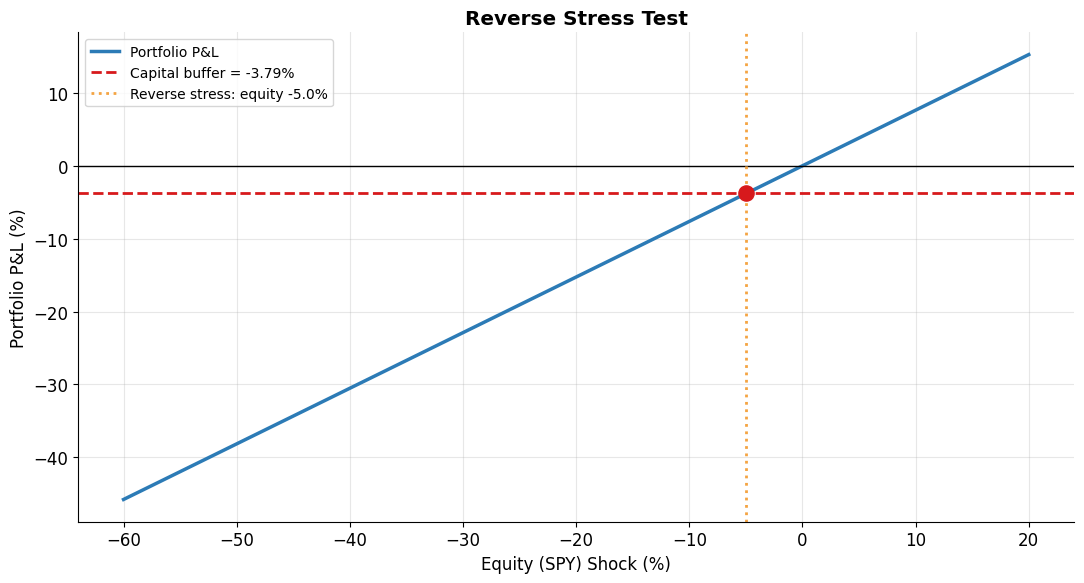

In [8]:
NAV_BN = float(total_assets)
excess_cet1 = max(cet1_ratio-7.0,0)/100*float(total_rwa)
capital_buffer_pct = excess_cet1/NAV_BN
port_beta_eq = sum(betas_df.loc[t,'beta_eq']*w for t,w in PORTFOLIO.items())
port_beta_rate = sum(betas_df.loc[t,'beta_rate']*w for t,w in PORTFOLIO.items())
delta_star_eq = -capital_buffer_pct/port_beta_eq if port_beta_eq else np.nan
delta_star_rate = -capital_buffer_pct/port_beta_rate if port_beta_rate else np.nan
print(f'CET1 {cet1_ratio:.2f}% | Excess above 7% floor ${excess_cet1:.1f}Bn ({capital_buffer_pct*100:.2f}% of NAV)')
print(f'Weighted betas: eq {port_beta_eq:.3f}, rate {port_beta_rate:.3f}')
print(f'Reverse stress: equity shock {delta_star_eq*100:+.1f}% or TLT shock {delta_star_rate*100:+.1f}% wipes the buffer')

eq_range = np.linspace(-0.60, 0.20, 200)
pnl_range = [sum(betas_df.loc[t,'beta_eq']*d*w for t,w in PORTFOLIO.items())*100 for d in eq_range]
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(eq_range*100, pnl_range, color=BLUE, lw=2.5, label='Portfolio P&L')
ax.axhline(-capital_buffer_pct*100, color=RED, lw=2, ls='--', label=f'Capital buffer = {-capital_buffer_pct*100:.2f}%')
ax.axhline(0, color='black', lw=1)
if not np.isnan(delta_star_eq):
    ax.axvline(delta_star_eq*100, color=GOLD, lw=2, ls=':', label=f'Reverse stress: equity {delta_star_eq*100:+.1f}%')
    ax.scatter([delta_star_eq*100], [-capital_buffer_pct*100], color=RED, s=120, zorder=10)
ax.set_xlabel('Equity (SPY) Shock (%)'); ax.set_ylabel('Portfolio P&L (%)'); ax.set_title('Reverse Stress Test', fontweight='bold'); ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

---
## Part 5 - Integrated Dashboard: Capital Adequacy Under Stress

We now combine all results into a single regulatory dashboard - capital ratios before and after each stress scenario, and flag pass / fail at the 7 % CET1 floor.

Pre-stress CET1 ratio: 15.8%
                              P&L (%)  P&L ($Bn)  CET1 post ($Bn)  CET1 ratio post (%) Pass/Fail (>=7%)
Scenario                                                                                               
COVID crash (Feb-Mar 2020)     -26.58    -175.43          -130.43                 0.00             FAIL
2022 drawdown (Jan-Oct 2022)   -23.33    -153.96          -108.96                 0.00             FAIL
Equity -30%                    -22.89    -151.09          -106.09                 0.00             FAIL
Rates +200bp                    -2.06     -13.61            31.39                11.06             PASS
Combined shock                 -24.95    -164.70          -119.70                 0.00             FAIL
Mild stress                     -8.15     -53.76            -8.76                 0.00             FAIL


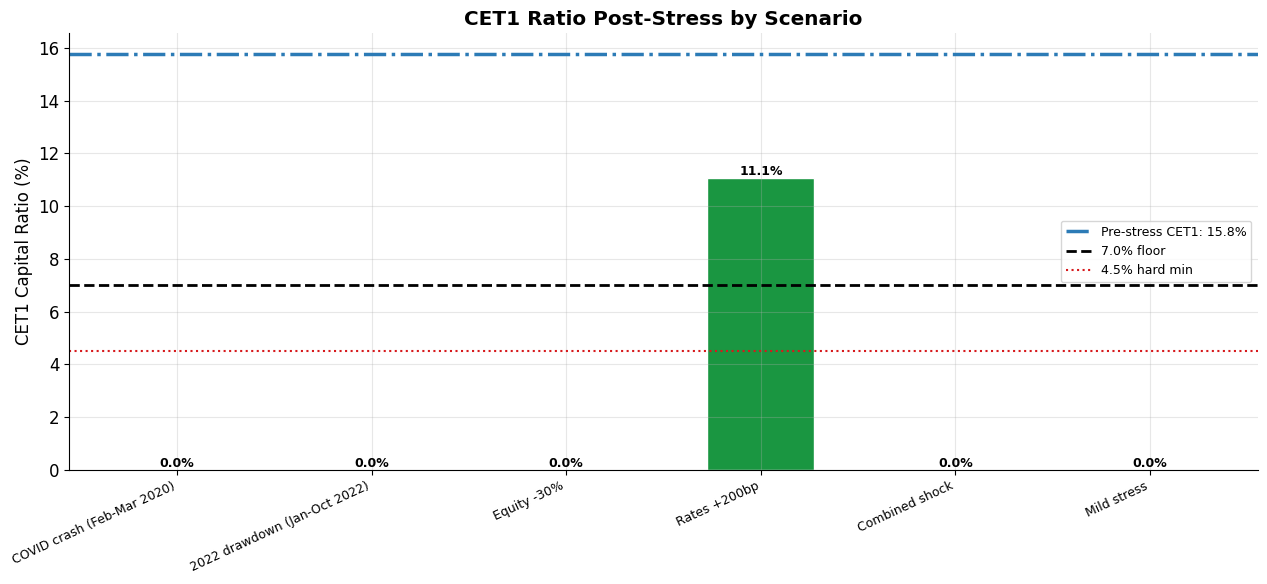

In [9]:
all_scenarios = {name:res['Total Return'] for name,res in scenario_results.items()}
all_scenarios.update({scen:res['total_pnl'] for scen,res in hypo_results.items()})
rows = []
for scen,pnl in all_scenarios.items():
    loss_bn = pnl*NAV_BN; new_cet1 = cet1_capital+loss_bn
    new_rwa = float(total_rwa)*(1+0.02*loss_bn/cet1_capital)
    new_ratio = max(new_cet1/new_rwa*100, 0)
    rows.append({'Scenario':scen,'P&L (%)':pnl*100,'P&L ($Bn)':loss_bn,'CET1 post ($Bn)':new_cet1,'CET1 ratio post (%)':new_ratio,'Pass/Fail (>=7%)':'PASS' if new_ratio>=7 else 'FAIL'})
summary_df = pd.DataFrame(rows).set_index('Scenario')
print(f'Pre-stress CET1 ratio: {cet1_ratio:.1f}%'); print(summary_df.round(2).to_string())

fig, ax = plt.subplots(figsize=(13, 6))
vals = summary_df['CET1 ratio post (%)'].values
bars = ax.bar(range(len(summary_df)), vals, color=[GREEN if v>=7 else RED for v in vals], edgecolor='white', width=0.55)
ax.axhline(cet1_ratio, color=BLUE, lw=2.5, ls='-.', label=f'Pre-stress CET1: {cet1_ratio:.1f}%')
ax.axhline(7.0, color='black', lw=2, ls='--', label='7.0% floor'); ax.axhline(4.5, color=RED, lw=1.5, ls=':', label='4.5% hard min')
for bar,v in zip(bars,vals): ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(range(len(summary_df))); ax.set_xticklabels(summary_df.index, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('CET1 Capital Ratio (%)'); ax.set_title('CET1 Ratio Post-Stress by Scenario', fontweight='bold'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

---
## Part 6 - Systemic Risk: CoVaR and Delta-CoVaR

<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">Theory</b> · CoVaR and ΔCoVaR (Adrian &amp; Brunnermeier 2016)</div>

**CoVaR** is the Value-at-Risk of the *system* (here, the S&P 500) *conditional* on institution $i$ being in distress:

$$\text{CoVaR}^{\text{sys}|i}_{\alpha} = \widehat{\alpha}\text{-quantile of }R^{\text{sys}} \mid R^{i} = \text{VaR}^{i}_{\alpha}$$

**ΔCoVaR** isolates the *marginal* contribution of firm $i$ to system risk:

$$\Delta\text{CoVaR}^{\text{sys}|i}_{\alpha} = \text{CoVaR}^{\text{sys}|i\text{ distressed}} - \text{CoVaR}^{\text{sys}|i\text{ median}}$$

Estimation uses **quantile regression** (Koenker & Bassett 1978):

$$\min_{\beta_0, \beta_1} \sum_t \rho_\alpha\!\left(R^{\text{sys}}_t - \beta_0 - \beta_1 R^{i}_t\right)$$

where $\rho_\alpha(u) = u(\alpha - \mathbf{1}_{u<0})$ is the check / pinball loss.

In [10]:
ALPHA = 0.05
covar_results = {}
for ticker in BANK_TICKERS:
    common = bank_rets[ticker].dropna().index.intersection(system_ret.dropna().index)
    y = system_ret.loc[common].values; Xb = bank_rets[ticker].loc[common].values
    qr = QuantReg(y, np.column_stack([np.ones(len(Xb)), Xb])).fit(q=ALPHA, max_iter=2000)
    beta0, beta1 = qr.params
    covar_d = beta0+beta1*np.percentile(Xb, ALPHA*100); covar_n = beta0+beta1*np.median(Xb)
    covar_results[ticker] = {'VaR_bank_5pct (%)':np.percentile(Xb,ALPHA*100)*100,'CoVaR_distressed (%)':covar_d*100,'CoVaR_normal (%)':covar_n*100,'DeltaCoVaR (%)':(covar_d-covar_n)*100}
covar_df = pd.DataFrame(covar_results).T
print('CoVaR (QuantReg, alpha=5%):'); print(covar_df.round(3).to_string())

CoVaR (QuantReg, alpha=5%):
     VaR_bank_5pct (%)  CoVaR_distressed (%)  CoVaR_normal (%)  DeltaCoVaR (%)
JPM             -2.385                -2.512            -1.300          -1.213
BAC             -2.663                -2.496            -1.387          -1.109
GS              -2.515                -2.333            -1.255          -1.078
C               -2.686                -2.458            -1.326          -1.132
MS              -2.775                -2.421            -1.301          -1.120


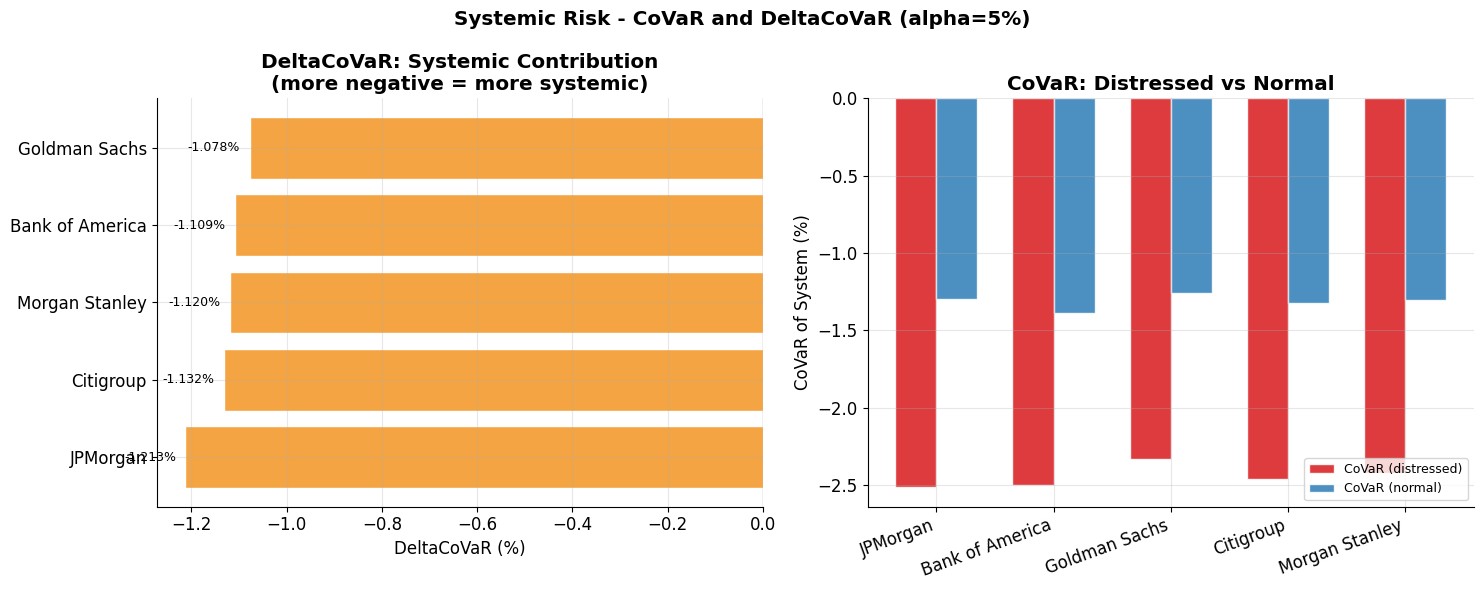

Most systemic: JPMorgan (DeltaCoVaR -1.213%)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
delta_vals = covar_df['DeltaCoVaR (%)'].sort_values()
bars = axes[0].barh([BANK_NAMES[t] for t in delta_vals.index], delta_vals.values,
                    color=[RED if v<-1.5 else (GOLD if v<-1.0 else GREEN) for v in delta_vals], edgecolor='white')
axes[0].axvline(0, color='black', lw=0.8); axes[0].set_title('DeltaCoVaR: Systemic Contribution\n(more negative = more systemic)', fontweight='bold'); axes[0].set_xlabel('DeltaCoVaR (%)')
for bar,val in zip(bars, delta_vals.values): axes[0].text(val-0.02, bar.get_y()+bar.get_height()/2, f'{val:.3f}%', ha='right', va='center', fontsize=9)
x_pos = np.arange(len(BANK_TICKERS)); w = 0.35
axes[1].bar(x_pos-w/2, covar_df.loc[BANK_TICKERS,'CoVaR_distressed (%)'], w, color=RED, alpha=0.85, label='CoVaR (distressed)', edgecolor='white')
axes[1].bar(x_pos+w/2, covar_df.loc[BANK_TICKERS,'CoVaR_normal (%)'], w, color=BLUE, alpha=0.85, label='CoVaR (normal)', edgecolor='white')
axes[1].set_xticks(x_pos); axes[1].set_xticklabels([BANK_NAMES[t] for t in BANK_TICKERS], rotation=20, ha='right')
axes[1].set_ylabel('CoVaR of System (%)'); axes[1].set_title('CoVaR: Distressed vs Normal', fontweight='bold'); axes[1].legend(fontsize=9)
plt.suptitle('Systemic Risk - CoVaR and DeltaCoVaR (alpha=5%)', fontweight='bold'); plt.tight_layout(); plt.show()
print(f'Most systemic: {BANK_NAMES[delta_vals.idxmin()]} (DeltaCoVaR {delta_vals.min():.3f}%)')

---
## Part 7 - Marginal Expected Shortfall (MES) and SRISK

<div style="border-left:5px solid #1A9641;background:#071A0F;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">Theory</b> · MES (Acharya et al. 2017) and SRISK (Brownlees &amp; Engle 2017)</div>

**Marginal Expected Shortfall** measures how much a firm loses when the system is in its worst tail:

$$\text{MES}_i = E\left[R_i \mid R^{\text{sys}} \le \text{VaR}^{\text{sys}}_\alpha\right]$$

**SRISK** estimates the capital shortfall a firm would face in a market crash:

$$\text{SRISK}_i = \max\!\bigl(0,\; k\cdot\text{Debt}_i - (1-k)\cdot\text{LRMES}_i\cdot\text{Equity}_i\bigr)$$

where $k=8\%$ is the prudential capital ratio and **LRMES** is the long-run MES approximated as:

$$\text{LRMES}_i \approx 1 - e^{126 \times \text{MES}^{\text{daily}}_i}$$

The intuition: a firm with a large positive SRISK would require a bailout in a 40% market crash.

In [12]:
SYS_VaR_THRESHOLD = np.percentile(system_ret.dropna(), 5)
def compute_mes(bank_ret, sys_ret, thr):
    mask = sys_ret <= thr; return bank_ret[mask].mean() if mask.sum()>0 else np.nan
full_mes = {t:compute_mes(bank_rets[t], system_ret, SYS_VaR_THRESHOLD) for t in BANK_TICKERS}
mes_series = pd.Series(full_mes, name='MES (%)')
print(f'System 5th-pctile day: {SYS_VaR_THRESHOLD*100:.3f}%')
for t,v in sorted(full_mes.items(), key=lambda x:x[1]): print(f'  {BANK_NAMES[t]:20s} MES {v*100:.3f}%')

k_capital = 0.08
bank_balance = pd.DataFrame({'Equity_Bn':{'JPM':340,'BAC':280,'GS':110,'C':130,'MS':115},
                             'Debt_Bn':{'JPM':3200,'BAC':2600,'GS':1200,'C':2100,'MS':1050}})
bank_balance['MES_daily'] = pd.Series(full_mes)
bank_balance['LRMES'] = 1-np.exp(126*bank_balance['MES_daily'])
bank_balance['SRISK_Bn'] = np.maximum(0, k_capital*bank_balance['Debt_Bn'] - (1-k_capital)*bank_balance['LRMES']*bank_balance['Equity_Bn'])
print('\nSRISK ($Bn):'); print(bank_balance[['Equity_Bn','Debt_Bn','MES_daily','LRMES','SRISK_Bn']].round(3).to_string())

System 5th-pctile day: -1.660%
  Morgan Stanley       MES -3.070%
  Citigroup            MES -2.835%
  Goldman Sachs        MES -2.785%
  Bank of America      MES -2.614%
  JPMorgan             MES -2.342%

SRISK ($Bn):
     Equity_Bn  Debt_Bn  MES_daily  LRMES  SRISK_Bn
JPM        340     3200     -0.023  0.948     0.000
BAC        280     2600     -0.026  0.963     0.000
GS         110     1200     -0.028  0.970     0.000
C          130     2100     -0.028  0.972    51.759
MS         115     1050     -0.031  0.979     0.000


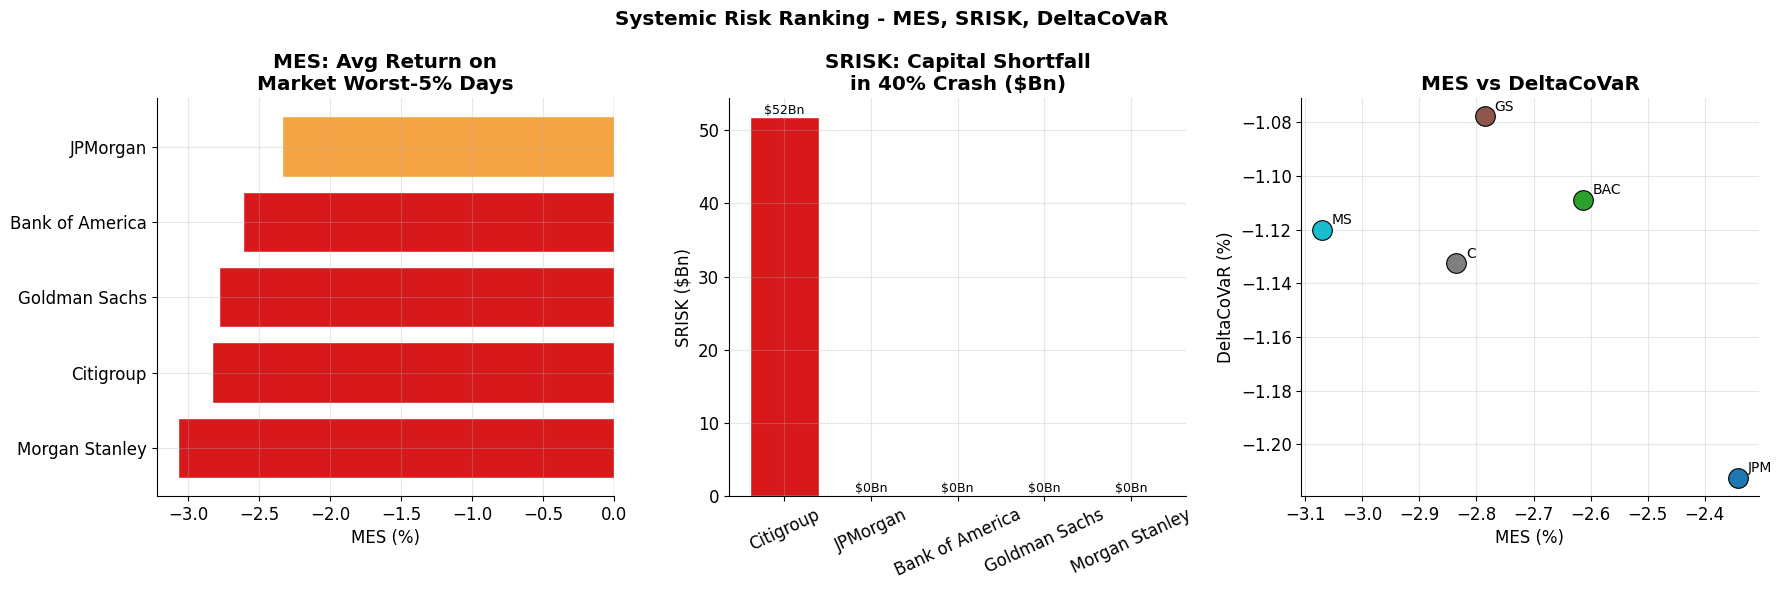

Systemic-Risk Ranking:
                 MES (%)  DeltaCoVaR (%)  SRISK ($Bn)  LRMES
Morgan Stanley    -3.070          -1.120        0.000  0.979
Citigroup         -2.835          -1.132       51.759  0.972
Goldman Sachs     -2.785          -1.078        0.000  0.970
Bank of America   -2.614          -1.109        0.000  0.963
JPMorgan          -2.342          -1.213        0.000  0.948


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
mes_sorted = mes_series.sort_values()
axes[0].barh([BANK_NAMES[t] for t in mes_sorted.index], mes_sorted.values*100,
             color=[RED if v<-0.025 else (GOLD if v<-0.015 else GREEN) for v in mes_sorted.values], edgecolor='white')
axes[0].axvline(0, color='black', lw=0.8); axes[0].set_title('MES: Avg Return on\nMarket Worst-5% Days', fontweight='bold'); axes[0].set_xlabel('MES (%)')
srisk_sorted = bank_balance['SRISK_Bn'].sort_values(ascending=False)
bars2 = axes[1].bar([BANK_NAMES[t] for t in srisk_sorted.index], srisk_sorted.values,
                    color=[RED if v>50 else (GOLD if v>20 else GREEN) for v in srisk_sorted.values], edgecolor='white')
for bar,val in zip(bars2, srisk_sorted.values): axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'${val:.0f}Bn', ha='center', fontsize=9)
axes[1].set_title('SRISK: Capital Shortfall\nin 40% Crash ($Bn)', fontweight='bold'); axes[1].set_ylabel('SRISK ($Bn)'); axes[1].tick_params(axis='x', rotation=25)
for t,col in zip(BANK_TICKERS, cm.tab10(np.linspace(0,1,len(BANK_TICKERS)))):
    axes[2].scatter(full_mes[t]*100, covar_df.loc[t,'DeltaCoVaR (%)'], s=200, color=col, edgecolors='black', lw=0.8, zorder=5)
    axes[2].annotate(t, (full_mes[t]*100, covar_df.loc[t,'DeltaCoVaR (%)']), textcoords='offset points', xytext=(7,4), fontsize=10)
axes[2].set_xlabel('MES (%)'); axes[2].set_ylabel('DeltaCoVaR (%)'); axes[2].set_title('MES vs DeltaCoVaR', fontweight='bold')
plt.suptitle('Systemic Risk Ranking - MES, SRISK, DeltaCoVaR', fontweight='bold'); plt.tight_layout(); plt.show()
ranking = pd.DataFrame({'MES (%)':mes_series*100,'DeltaCoVaR (%)':covar_df.loc[BANK_TICKERS,'DeltaCoVaR (%)'],'SRISK ($Bn)':bank_balance['SRISK_Bn'],'LRMES':bank_balance['LRMES']})
ranking.index = [BANK_NAMES[t] for t in ranking.index]
print('Systemic-Risk Ranking:'); print(ranking.sort_values('MES (%)').round(3).to_string())

---
## Part 8 - Model Risk: VaR Sensitivity to Modelling Choices

<div style="border-left:5px solid #D7191C;background:#200A0A;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#FF9999">Model Risk</b> · The Financial Risk Manager Handbook definition</div>

**Model risk** is the risk of a financial loss arising from an incorrect or misapplied model. It arises from:

1. **Distributional mis-specification** - using Normal VaR when returns are fat-tailed
2. **Parameter instability** - estimates change as the estimation window shifts
3. **Model selection** - different coherent models give materially different answers

We demonstrate all three using S&P 500 returns, then extend to bank returns.

$$\text{VaR}_{\alpha}^{\text{Normal}} = \hat{\mu} + \hat{\sigma}\cdot z_{\alpha}$$
$$\text{VaR}_{\alpha}^{\text{t}} = \hat{\mu} + \hat{s}\cdot t_{\alpha, \hat{\nu}}$$
$$\text{VaR}_{\alpha}^{\text{HS}} = \text{Empirical quantile}_{\alpha}$$

In [14]:
ALPHA_VAR = 0.01
FOCAL = 'JPM'
def var_normal(r, a): return -(r.mean()+r.std()*norm.ppf(a))
def var_t(r, a):
    nu,loc,scale = t_dist.fit(r); return -(loc+scale*t_dist.ppf(a,nu))
def var_hs(r, a): return -np.percentile(r, a*100)
var_table = {}
for t in BANK_TICKERS:
    r = bank_rets[t].dropna()
    var_table[t] = {'Normal VaR (%)':var_normal(r,ALPHA_VAR)*100,'t-dist VaR (%)':var_t(r,ALPHA_VAR)*100,'Historical VaR (%)':var_hs(r,ALPHA_VAR)*100,'Excess Kurtosis':r.kurt()}
var_df = pd.DataFrame(var_table).T
print('99% Daily VaR by Method:'); print(var_df.round(3).to_string())

99% Daily VaR by Method:
     Normal VaR (%)  t-dist VaR (%)  Historical VaR (%)  Excess Kurtosis
JPM           3.517           4.038               4.323            4.617
BAC           3.893           4.481               3.999            3.696
GS            4.020           4.515               4.465            4.799
C             4.192           4.708               4.539            5.260
MS            4.126           4.723               5.041            3.782


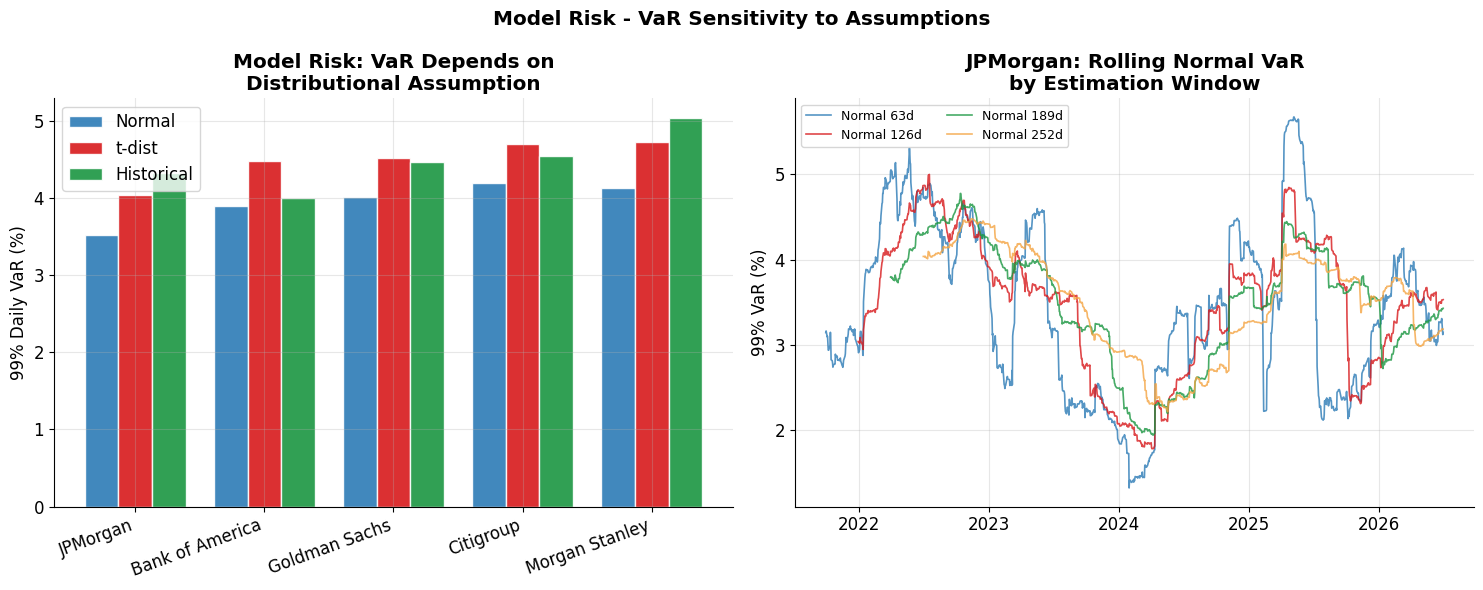

Model-risk ratio (max/min VaR):
     Normal VaR (%)  t-dist VaR (%)  Historical VaR (%)  Model-Risk Ratio
JPM           3.517           4.038               4.323             1.229
BAC           3.893           4.481               3.999             1.151
GS            4.020           4.515               4.465             1.123
C             4.192           4.708               4.539             1.123
MS            4.126           4.723               5.041             1.222


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
x_pos = np.arange(len(BANK_TICKERS)); w = 0.26
axes[0].bar(x_pos-w, var_df['Normal VaR (%)'], w, color=BLUE, alpha=0.9, label='Normal', edgecolor='white')
axes[0].bar(x_pos, var_df['t-dist VaR (%)'], w, color=RED, alpha=0.9, label='t-dist', edgecolor='white')
axes[0].bar(x_pos+w, var_df['Historical VaR (%)'], w, color=GREEN, alpha=0.9, label='Historical', edgecolor='white')
axes[0].set_xticks(x_pos); axes[0].set_xticklabels([BANK_NAMES[t] for t in BANK_TICKERS], rotation=20, ha='right')
axes[0].set_ylabel('99% Daily VaR (%)'); axes[0].set_title('Model Risk: VaR Depends on\nDistributional Assumption', fontweight='bold'); axes[0].legend()
for W,col in zip([63,126,189,252],[BLUE,RED,GREEN,GOLD]):
    axes[1].plot(r_focal.index, r_focal.rolling(W).apply(lambda r:var_normal(r,ALPHA_VAR), raw=False)*100, color=col, lw=1.2, alpha=0.8, label=f'Normal {W}d')
axes[1].set_title(f'{BANK_NAMES[FOCAL]}: Rolling Normal VaR\nby Estimation Window', fontweight='bold'); axes[1].set_ylabel('99% VaR (%)'); axes[1].legend(fontsize=9, ncol=2)
plt.suptitle('Model Risk - VaR Sensitivity to Assumptions', fontweight='bold'); plt.tight_layout(); plt.show()
cols3 = ['Normal VaR (%)','t-dist VaR (%)','Historical VaR (%)']
var_df['Model-Risk Ratio'] = var_df[cols3].max(axis=1)/var_df[cols3].min(axis=1)
print('Model-risk ratio (max/min VaR):'); print(var_df[cols3+['Model-Risk Ratio']].round(3).to_string())

---
## Part 9 - Regime Detection: Crisis vs Normal

<div style="border-left:5px solid #F4A442;background:#1A1000;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#FFD080">Regime Detection</b> · Adapted from the regime-switching teaching materials</div>

Financial time series exhibit **regime switching**: returns are not i.i.d. - they cluster into distinct states (calm / crisis). Two complementary approaches:

1. **Rolling-volatility indicator**: flag crisis when 21-day realized vol exceeds a threshold
2. **Gaussian Mixture Model (GMM)**: fit a 2-component mixture to identify high/low-vol states

Regime awareness matters for model risk: a VaR estimated in calm periods will **systematically under-predict** losses in crisis regimes.

In [16]:
ROLL_VOL_WIN, CRISIS_THRESH = 21, 0.20
roll_vol_spy = r_spy.rolling(ROLL_VOL_WIN).std()*np.sqrt(252)
pct_crisis = (roll_vol_spy>CRISIS_THRESH).mean()*100
r_clean = r_spy.dropna().values.reshape(-1,1)
gmm = GaussianMixture(n_components=2, random_state=42, max_iter=500).fit(r_clean)
gmm_labels = gmm.predict(r_clean); gmm_proba = gmm.predict_proba(r_clean)
comp_stds = np.sqrt(gmm.covariances_.flatten())
crisis_comp = int(np.argmax(comp_stds)); calm_comp = 1-crisis_comp
gmm_crisis_prob = pd.Series(gmm_proba[:,crisis_comp], index=r_spy.dropna().index)
print(f'Rolling-vol regime: {pct_crisis:.1f}% of days crisis (>{CRISIS_THRESH*100:.0f}% ann vol)')
print(f'GMM means: calm {gmm.means_[calm_comp][0]*100:.3f}%, crisis {gmm.means_[crisis_comp][0]*100:.3f}%')
print(f'GMM stds: calm {comp_stds[calm_comp]*100:.2f}%, crisis {comp_stds[crisis_comp]*100:.2f}%')
crisis_idx = r_spy.dropna().index[gmm_labels==crisis_comp]; calm_idx = r_spy.dropna().index[gmm_labels==calm_comp]
for name,idx in [('Calm',calm_idx),('Crisis',crisis_idx)]:
    r_sub = r_focal.reindex(idx).dropna()
    if len(r_sub)>20: print(f'{name} regime ({len(r_sub)}d) - {BANK_NAMES[FOCAL]} 99% VaR: Normal {var_normal(r_sub,0.01)*100:.3f}%, Historical {var_hs(r_sub,0.01)*100:.3f}%')

Rolling-vol regime: 18.9% of days crisis (>20% ann vol)
GMM means: calm 0.124%, crisis -0.156%
GMM stds: calm 0.71%, crisis 1.65%
Calm regime (1081d) - JPMorgan 99% VaR: Normal 2.780%, Historical 3.893%
Crisis regime (172d) - JPMorgan 99% VaR: Normal 6.607%, Historical 6.842%


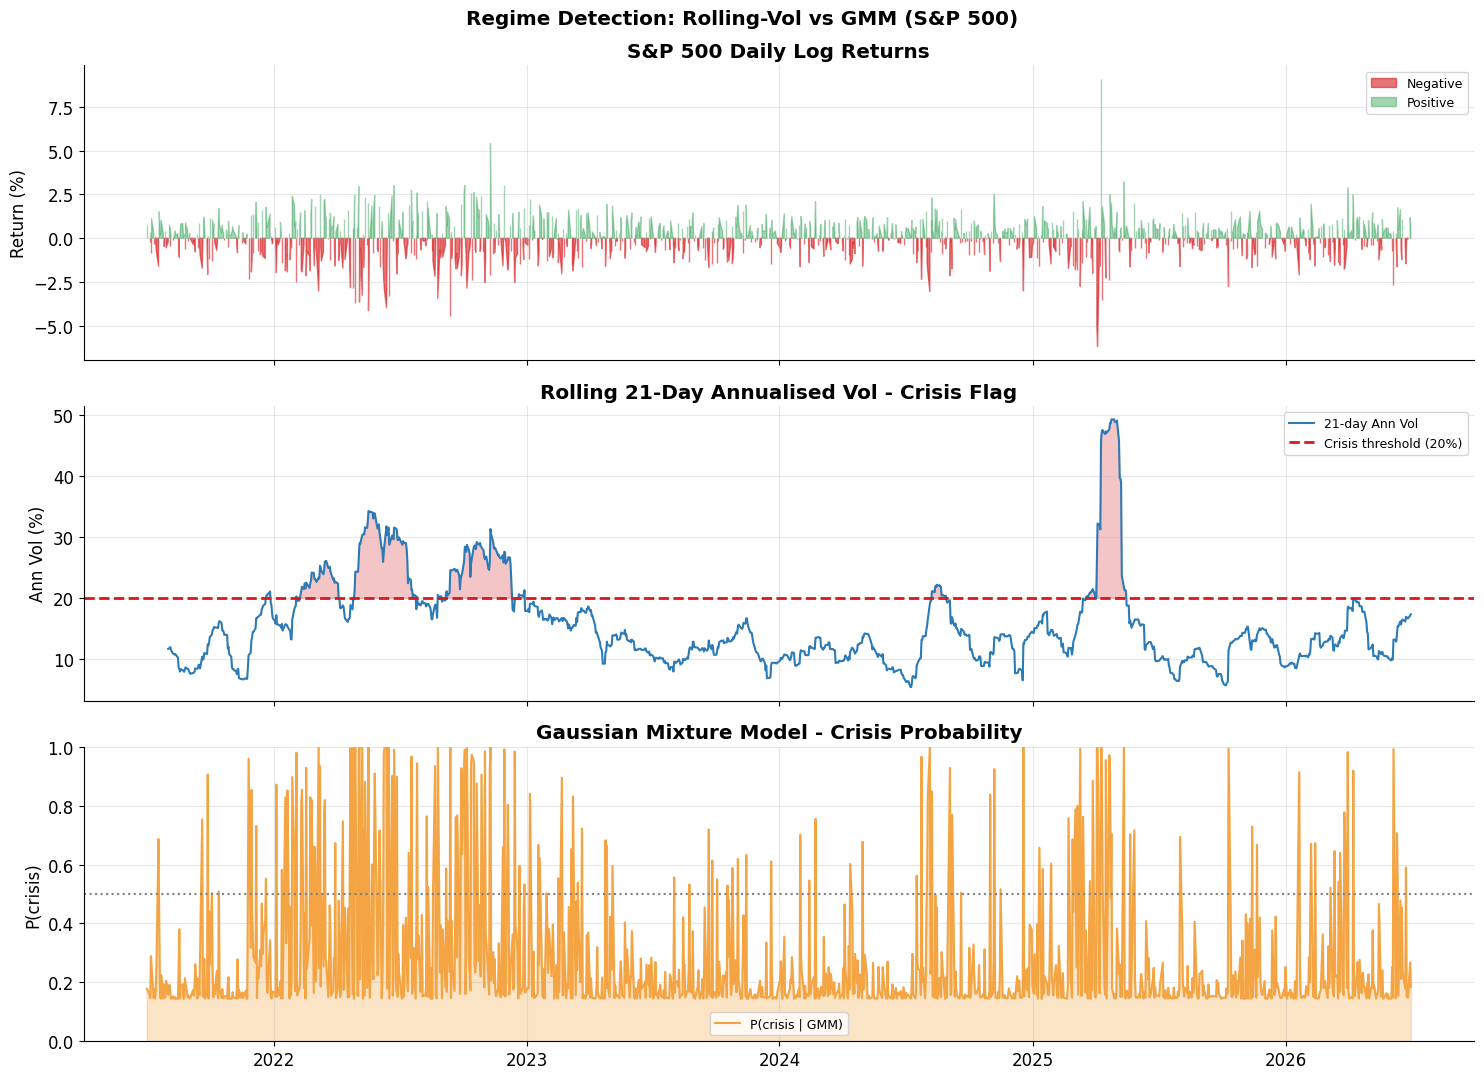

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)
ci = r_spy.dropna().index
axes[0].fill_between(ci, r_spy.reindex(ci)*100, 0, where=r_spy.reindex(ci)<0, color=RED, alpha=0.6, label='Negative')
axes[0].fill_between(ci, r_spy.reindex(ci)*100, 0, where=r_spy.reindex(ci)>=0, color=GREEN, alpha=0.4, label='Positive')
axes[0].set_title('S&P 500 Daily Log Returns', fontweight='bold'); axes[0].set_ylabel('Return (%)'); axes[0].legend(fontsize=9)
axes[1].plot(roll_vol_spy.index, roll_vol_spy*100, color=BLUE, lw=1.5, label='21-day Ann Vol')
axes[1].axhline(CRISIS_THRESH*100, color=RED, ls='--', lw=2, label=f'Crisis threshold ({CRISIS_THRESH*100:.0f}%)')
axes[1].fill_between(roll_vol_spy.index, roll_vol_spy*100, CRISIS_THRESH*100, where=roll_vol_spy>CRISIS_THRESH, color=RED, alpha=0.25)
axes[1].set_title('Rolling 21-Day Annualised Vol - Crisis Flag', fontweight='bold'); axes[1].set_ylabel('Ann Vol (%)'); axes[1].legend(fontsize=9)
axes[2].plot(gmm_crisis_prob.index, gmm_crisis_prob.values, color=GOLD, lw=1.5, label='P(crisis | GMM)')
axes[2].axhline(0.5, color='grey', ls=':', lw=1.5); axes[2].fill_between(gmm_crisis_prob.index, gmm_crisis_prob.values, alpha=0.3, color=GOLD)
axes[2].set_title('Gaussian Mixture Model - Crisis Probability', fontweight='bold'); axes[2].set_ylabel('P(crisis)'); axes[2].set_ylim(0,1); axes[2].legend(fontsize=9)
plt.suptitle('Regime Detection: Rolling-Vol vs GMM (S&P 500)', fontweight='bold'); plt.tight_layout(); plt.show()

---
## Session Summary

**Regulatory capital.** CET1, Tier-1, Total Capital, the Leverage Ratio and the liquidity ratios (LCR, NSFR) form the Basel III quantitative framework. Ratios are measured against risk-weighted assets, not gross exposure.

**Market-risk capital.** Basel 2.5 adds a Stressed VaR charge on top of standard VaR; FRTB replaces VaR with 97.5% Expected Shortfall. Stressed VaR here runs several times the calm-period VaR.

**Stress testing.** Three lenses: historical replay (COVID-2020, 2022), hypothetical factor shocks (equity and rate), and a two-factor sensitivity grid. Reverse stress testing solves for the shock that exactly exhausts the capital buffer.

**Systemic risk.** CoVaR and Delta-CoVaR measure a firm's contribution to system tail risk (quantile regression); MES and SRISK measure loss on the market's worst days and the capital shortfall in a crash. These are the market-based analogue of the G-SIB surcharge.

**Model risk.** The same portfolio gives materially different VaR under Normal, t and Historical methods, and the estimate drifts with the estimation window. This is why the Basel output floor and FRTB constrain internal models.

**Regime detection.** A rolling-volatility flag and a Gaussian Mixture Model both separate calm from crisis states; VaR is much larger conditional on the crisis regime.

**Climate / ESG risk** is covered on the slides (physical vs transition risk, NGFS scenarios, the Green Swan).